<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Reinforcement-Learning/blob/master/LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a target="_blank" href="https://colab.research.google.com/github/mim-ml-teaching/public-rl-2025-26/blob/main/labs/RL_LAB3_decision_transformer.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Lab 03: Decision Transformer

From blogpost https://sites.google.com/berkeley.edu/decision-transformer

### Offline reinforcement learning as a sequence modeling problem

We investigate shifting our perspective of reinforcement learning (RL) by posing sequential decision making problems in a language modeling framework. While conventional work in RL has utilized specialized frameworks relying on Bellman backups, we propose to instead model trajectories with sequence modeling, enabling us to use strong and well-studied architectures such as transformers to generate behaviors. To illustrate this, we study offline reinforcement learning, where we train a model from a fixed dataset rather than collecting experience in the environment. This enables us to train RL policies using the same code as a language modeling framework, with minimal changes.

### Decision Transformer: autoregressive sequence modeling for RL

We take a simple approach: each modality (return, state, or action) is passed into an embedding network (convolutional encoder for images, linear layer for continuous states). The embeddings are then processed by an autoregressive transformer model, trained to predict the next action given the previous tokens using a linear output layer.

Evaluation is also easy: we can initialize by a desired target return (e.g. 1 or 0 for success or failure) and the starting state in the environment. Unrolling the sequence -- similar to standard autoregressive generation in language models -- yields a sequence of actions to execute in the environment.

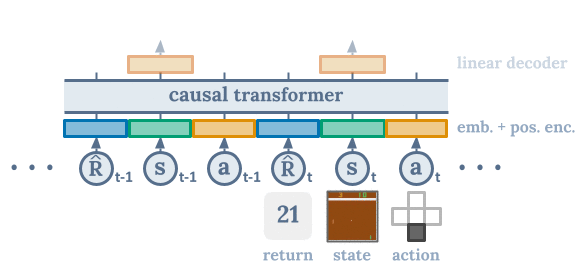

### Stitching subsequences to produce optimal trajectories

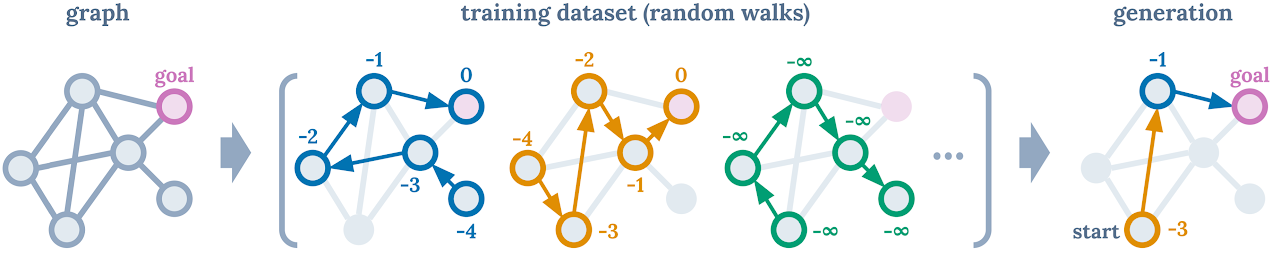

Consider the task of finding the shortest path on a fixed graph, posed as a reinforcement learning problem (accumulated reward = sum of edge weights). In a training dataset consisting of random walks, we observe many suboptimal trajectories. If we train Decision Transformer on these sequences, we can ask the model to generate an optimal path by conditioning on a large return. We find that by training on only random walks, Decision Transformer can learn to stitch together subsequences from different training trajectories in order to produce optimal trajectories at test time!

In fact, this is the same behavior which is desired from off-policy Q-learning algorithms commonly used in offline reinforcement learning frameworks. However, without needing to introduce TD learning algorithms, value pessimism, or behavior regularization , we can achieve the same behavior using a sequence modeling framework!

%%html
<video controls autoplay><source src="https://huggingface.co/edbeeching/decision-transformer-gym-halfcheetah-expert/resolve/main/replay.mp4" type="video/mp4"></video>

### Step 1: Install dependencies for model evaluation 🔽

In [1]:
import os
import subprocess

if "COLAB_RELEASE_TAG" in os.environ:
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "ffmpeg"], check=False)
else:
    print("Skipping apt-get setup outside Colab.")

In [2]:
%pip install -q --upgrade --no-cache-dir "transformers>=4.40,<5.0" "datasets>=2.18,<3.0" "accelerate>=1.1,<2.0" "huggingface_hub>=0.23,<1.0"
%pip install -q --upgrade --no-cache-dir "gymnasium[mujoco]>=0.29,<1.0" "imageio>=2.34" "imageio-ffmpeg>=0.4.9"
print("If this is the first run after installing packages in Colab, restart runtime and run all cells again.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 158.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 197.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 198.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 192.8 MB/s eta 0:00:00
ERROR: 

### Step 2: Install and import the packages 📦



In [3]:
import inspect
import os
import random
from dataclasses import dataclass

import accelerate
import numpy as np
import torch
import transformers
from datasets import load_dataset
from transformers import DecisionTransformerConfig, Trainer, TrainingArguments

print(f"transformers=={transformers.__version__}, accelerate=={accelerate.__version__}")
if "keep_torch_compile" not in inspect.signature(accelerate.Accelerator.unwrap_model).parameters:
    raise RuntimeError(
        "Incompatible accelerate version detected for current transformers Trainer. "
        "Run the install cell, restart runtime, and run all cells from the top."
    )

transformers==4.57.6, accelerate==1.13.0


### Step 3: Loading the dataset from the 🤗 Hub and instantiating the model

We host a number of Offline RL Datasets on the hub. Today we will be training with the halfcheetah “expert” dataset, hosted here on hub.

First we need to import the load_dataset function from the 🤗 datasets package and download the dataset to our machine.

In [4]:
os.environ["WANDB_DISABLED"] = "true" # we diable weights and biases logging for this tutorial
dataset = load_dataset("edbeeching/decision_transformer_gym_replay", "halfcheetah-expert-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

### Step 4: Defining a custom DataCollator for the transformers Trainer class

In [5]:
@dataclass
class DecisionTransformerGymDataCollator:
    return_tensors: str = "pt"
    max_len: int = 20 #subsets of the episode we use for training
    state_dim: int = 17  # size of state space
    act_dim: int = 6  # size of action space
    max_ep_len: int = 1000 # max episode length in the dataset
    scale: float = 1000.0  # normalization of rewards/returns
    state_mean: np.array = None  # to store state means
    state_std: np.array = None  # to store state stds
    p_sample: np.array = None  # a distribution to take account trajectory lengths
    n_traj: int = 0 # to store the number of trajectories in the dataset

    def __init__(self, dataset) -> None:
        self.act_dim = len(dataset[0]["actions"][0])
        self.state_dim = len(dataset[0]["observations"][0])
        self.dataset = dataset
        # calculate dataset stats for normalization of states
        states = []
        traj_lens = []
        for obs in dataset["observations"]:
            states.extend(obs)
            traj_lens.append(len(obs))
        self.n_traj = len(traj_lens)
        states = np.vstack(states)
        self.state_mean, self.state_std = np.mean(states, axis=0), np.std(states, axis=0) + 1e-6

        traj_lens = np.array(traj_lens)
        self.p_sample = traj_lens / sum(traj_lens)

    def _discount_cumsum(self, x, gamma):
        discount_cumsum = np.zeros_like(x)
        discount_cumsum[-1] = x[-1]
        for t in reversed(range(x.shape[0] - 1)):
            discount_cumsum[t] = x[t] + gamma * discount_cumsum[t + 1]
        return discount_cumsum

    def __call__(self, features):
        batch_size = len(features)
        # this is a bit of a hack to be able to sample of a non-uniform distribution
        batch_inds = np.random.choice(
            np.arange(self.n_traj),
            size=batch_size,
            replace=True,
            p=self.p_sample,  # reweights so we sample according to timesteps
        )
        # a batch of dataset features
        s, a, r, d, rtg, timesteps, mask = [], [], [], [], [], [], []

        for ind in batch_inds:
            # for feature in features:
            feature = self.dataset[int(ind)]
            si = random.randint(0, len(feature["rewards"]) - 1)

            # get sequences from dataset
            s.append(np.array(feature["observations"][si : si + self.max_len]).reshape(1, -1, self.state_dim))
            a.append(np.array(feature["actions"][si : si + self.max_len]).reshape(1, -1, self.act_dim))
            r.append(np.array(feature["rewards"][si : si + self.max_len]).reshape(1, -1, 1))

            d.append(np.array(feature["dones"][si : si + self.max_len]).reshape(1, -1))
            timesteps.append(np.arange(si, si + s[-1].shape[1]).reshape(1, -1))
            timesteps[-1][timesteps[-1] >= self.max_ep_len] = self.max_ep_len - 1  # padding cutoff
            rtg.append(
                self._discount_cumsum(np.array(feature["rewards"][si:]), gamma=1.0)[
                    : s[-1].shape[1]   # TODO check the +1 removed here
                ].reshape(1, -1, 1)
            )
            if rtg[-1].shape[1] < s[-1].shape[1]:
                print("if true")
                rtg[-1] = np.concatenate([rtg[-1], np.zeros((1, 1, 1))], axis=1)

            # padding and state + reward normalization
            tlen = s[-1].shape[1]
            s[-1] = np.concatenate([np.zeros((1, self.max_len - tlen, self.state_dim)), s[-1]], axis=1)
            s[-1] = (s[-1] - self.state_mean) / self.state_std
            a[-1] = np.concatenate(
                [np.ones((1, self.max_len - tlen, self.act_dim)) * -10.0, a[-1]],
                axis=1,
            )
            r[-1] = np.concatenate([np.zeros((1, self.max_len - tlen, 1)), r[-1]], axis=1)
            d[-1] = np.concatenate([np.ones((1, self.max_len - tlen)) * 2, d[-1]], axis=1)
            rtg[-1] = np.concatenate([np.zeros((1, self.max_len - tlen, 1)), rtg[-1]], axis=1) / self.scale
            timesteps[-1] = np.concatenate([np.zeros((1, self.max_len - tlen)), timesteps[-1]], axis=1)
            mask.append(np.concatenate([np.zeros((1, self.max_len - tlen)), np.ones((1, tlen))], axis=1))

        s = torch.from_numpy(np.concatenate(s, axis=0)).float()
        a = torch.from_numpy(np.concatenate(a, axis=0)).float()
        r = torch.from_numpy(np.concatenate(r, axis=0)).float()
        d = torch.from_numpy(np.concatenate(d, axis=0))
        rtg = torch.from_numpy(np.concatenate(rtg, axis=0)).float()
        timesteps = torch.from_numpy(np.concatenate(timesteps, axis=0)).long()
        mask = torch.from_numpy(np.concatenate(mask, axis=0)).float()

        return {
            "states": s,
            "actions": a,
            "rewards": r,
            "returns_to_go": rtg,
            "timesteps": timesteps,
            "attention_mask": mask,
        }

### Step 5: Implement Decition Transformer Model

In [7]:
from typing import Optional, Union, Tuple

import torch.nn as nn

from transformers.models.decision_transformer.modeling_decision_transformer import DecisionTransformerPreTrainedModel, DecisionTransformerOutput, DecisionTransformerGPT2Model


class DecisionTransformerModel(DecisionTransformerPreTrainedModel):
    """

    The model builds upon the GPT2 architecture to perform autoregressive prediction of actions in an offline RL
    setting. Refer to the paper for more details: https://arxiv.org/abs/2106.01345

    """

    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.hidden_size = config.hidden_size
        # note: the only difference between this GPT2Model and the default Huggingface version
        # is that the positional embeddings are removed (since we'll add those ourselves)
        self.encoder = DecisionTransformerGPT2Model(config)

        self.embed_timestep = nn.Embedding(config.max_ep_len, config.hidden_size)
        self.embed_return = torch.nn.Linear(1, config.hidden_size)
        self.embed_state = torch.nn.Linear(config.state_dim, config.hidden_size)
        self.embed_action = torch.nn.Linear(config.act_dim, config.hidden_size)

        self.embed_ln = nn.LayerNorm(config.hidden_size)

        # note: we don't predict states or returns for the paper
        self.predict_state = torch.nn.Linear(config.hidden_size, config.state_dim)
        self.predict_action = nn.Sequential(
            *([nn.Linear(config.hidden_size, config.act_dim)] + ([nn.Tanh()] if config.action_tanh else []))
        )
        self.predict_return = torch.nn.Linear(config.hidden_size, 1)

        # Initialize weights and apply final processing
        self.post_init()

    def forward(
        self,
        states: Optional[torch.FloatTensor] = None,
        actions: Optional[torch.FloatTensor] = None,
        rewards: Optional[torch.FloatTensor] = None,
        returns_to_go: Optional[torch.FloatTensor] = None,
        timesteps: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.FloatTensor] = None,
        output_hidden_states: Optional[bool] = None,
        output_attentions: Optional[bool] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple[torch.FloatTensor], DecisionTransformerOutput]:
        output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
        output_hidden_states = (
            output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
        )
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        batch_size, seq_length = states.shape[0], states.shape[1]

        if attention_mask is None:
            # attention mask for GPT: 1 if can be attended to, 0 if not
            attention_mask = torch.ones((batch_size, seq_length), dtype=torch.long)

        # =========================================================================
        # TASK 1: Embed the modalities and construct the sequence
        # =========================================================================

        # TODO 1.1: Embed states, actions, returns_to_go, and timesteps using the
        # linear/embedding layers defined in __init__.
        # YOUR CODE HERE
        state_embed = self.embed_state(states)
        action_embed = self.embed_action(actions)
        return_embed = self.embed_return(returns_to_go)
        timestep_embed = self.embed_timestep(timesteps)

        # (batch_size, seq_len, hidden_size)

        # TODO 1.2: Time embeddings are treated similarly to positional embeddings.
        # Add the time embeddings to your state, action, and return embeddings.
        # YOUR CODE HERE
        state_embed += timestep_embed
        action_embed += timestep_embed
        return_embed += timestep_embed

        # TODO 1.3: Stack the inputs to create the sequence (R_1, s_1, a_1, R_2, s_2, a_2, ...)
        # Hint: Use torch.stack to combine returns, states, and actions along a new dimension (dim=1).
        # Then permute and reshape it to achieve a final shape of: (batch_size, 3 * seq_length, hidden_size)
        # YOUR CODE HERE
        stacked_inputs = torch.stack((return_embed, state_embed, action_embed), dim=1)
        stacked_inputs = torch.permute(stacked_inputs, (0, 2, 1, 3)).reshape(batch_size, 3*seq_length, self.hidden_size)

        # TODO 1.4: Pass the stacked inputs through the LayerNorm (self.embed_ln)
        # YOUR CODE HERE
        stacked_inputs = self.embed_ln(stacked_inputs) # Replace with your normalized sequence

        # TODO 1.5: To make the attention mask fit the stacked inputs, you must stack it as well.
        # Hint: The mask currently applies to a whole timestep. You need to duplicate it for R, s, and a.
        # Final shape should be (batch_size, 3 * seq_length)
        # YOUR CODE HERE
        stacked_attention_mask = torch.stack((attention_mask, attention_mask, attention_mask), dim=1)# Replace with your stacked mask
        stacked_attention_mask = torch.permute(stacked_attention_mask, (0, 2, 1)).reshape(batch_size, 3*seq_length)

        # =========================================================================

        device = stacked_inputs.device
        # we feed in the input embeddings (not word indices as in NLP) to the model
        encoder_outputs = self.encoder(
            inputs_embeds=stacked_inputs,
            attention_mask=stacked_attention_mask,
            position_ids=torch.zeros(stacked_attention_mask.shape, device=device, dtype=torch.long),
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        x = encoder_outputs[0]

        # =========================================================================
        # TASK 2: Extract predictions from the transformer output
        # =========================================================================

        # TODO 2.1: Reshape `x` so that the second dimension corresponds to the original
        # returns (0), states (1), or actions (2).
        # i.e., x[:, 1, t] should be the token for state at timestep t.
        # Hint: Reshape to (batch_size, seq_length, 3, hidden_size) then permute the dimensions.
        # YOUR CODE HERE
        x = stacked_inputs.reshape(batch_size, seq_length, 3, self.hidden_size) # Replace with your reshaped output
        x = torch.permute(x, (0, 2, 1, 3))

        # TODO 2.2: Get predictions using the linear prediction layers in __init__.
        # Use the correct slice of `x` for each prediction:
        # - predict_return uses the action token (x[:, 2])
        # - predict_state uses the action token (x[:, 2])
        # - predict_action uses the state token (x[:, 1])
        # YOUR CODE HERE
        return_preds = self.predict_return(x[:, 2])
        state_preds = self.predict_state(x[:, 2])
        action_preds = self.predict_action(x[:, 1])

        # =========================================================================

        if not return_dict:
            return (state_preds, action_preds, return_preds)

        return DecisionTransformerOutput(
            last_hidden_state=encoder_outputs.last_hidden_state,
            state_preds=state_preds,
            action_preds=action_preds,
            return_preds=return_preds,
            hidden_states=encoder_outputs.hidden_states,
            attentions=encoder_outputs.attentions,
        )

### Step 6: Extending the Decision Transformer Model to include a loss function

In order to train the model with the 🤗 trainer class, we first need to ensure the dictionary it returns contains a loss, in this case L-2 norm of the models action predictions and the targets.

In [14]:
class TrainableDT(DecisionTransformerModel):
    def __init__(self, config):
        super().__init__(config)

    def forward(self, **kwargs):
        output = super().forward(**kwargs)

        # =========================================================================
        # TASK 3: Implement the Decision Transformer Loss
        # =========================================================================
        # The loss is the L-2 norm (Mean Squared Error) of the model's action
        # predictions against the target actions from the dataset.

        # 1. Extract the predicted actions from the model's output.
        action_preds = output[1]

        # 2. Extract the target actions and the attention mask from kwargs.
        action_targets = kwargs["actions"]
        attention_mask = kwargs["attention_mask"]

        # TODO 3.1: Reshape both `action_preds` and `action_targets` to be flat 2D tensors.
        # Next, filter out the padded elements using the `attention_mask`. You only
        # want to calculate loss where attention_mask > 0.
        # YOUR CODE HERE
        action_preds = action_preds.reshape(-1, self.config.act_dim)
        action_targets = action_targets.reshape(-1, self.config.act_dim)
        mask = attention_mask.reshape(-1)
        filtered_preds = action_preds[mask > 0]
        filtered_targets = action_targets[mask > 0]


        # TODO 3.2: Calculate the Mean Squared Error (MSE) loss between the
        # filtered predictions and filtered targets.
        # YOUR CODE HERE
        loss = nn.functional.mse_loss(filtered_preds, filtered_targets) # Replace with your calculated loss

        # =========================================================================

        return {"loss": loss}

    def original_forward(self, **kwargs):
        return super().forward(**kwargs)

In [15]:
collator = DecisionTransformerGymDataCollator(dataset["train"])

config = DecisionTransformerConfig(state_dim=collator.state_dim, act_dim=collator.act_dim)
model = TrainableDT(config)

### Step 7: Defining the training hyperparameters and training the model
Here, we define the training hyperparameters and our Trainer class that we'll use to train our Decision Transformer model.

This step takes about an hour, so you may leave it running. Note the authors train for at least 3 hours, so the results presented here are not as performant as the models hosted on the 🤗 hub.

In [16]:
training_args = TrainingArguments(
    output_dir="output/",
    remove_unused_columns=False,
    num_train_epochs=2,
    per_device_train_batch_size=64,
    learning_rate=1e-4,
    weight_decay=1e-4,
    warmup_ratio=0.1,
    optim="adamw_torch",
    max_grad_norm=0.25,
    report_to="none"  # Disable all logging services
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collator,
)

trainer.train()

Step,Training Loss


TrainOutput(global_step=32, training_loss=0.5631130933761597, metrics={'train_runtime': 101.5286, 'train_samples_per_second': 19.699, 'train_steps_per_second': 0.315, 'total_flos': 2455670400000.0, 'train_loss': 0.5631130933761597, 'epoch': 2.0})

In [17]:
checkpoint_path = "output/checkpoint-1500/"

# Load the model from the checkpoint
# We use TrainableDT so that the custom forward/loss logic is preserved
model = TrainableDT.from_pretrained(checkpoint_path)

print(f"Model successfully loaded from {checkpoint_path}")

HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': 'output/checkpoint-1500/'. Use `repo_type` argument if needed.

### Step 8: Visualize the performance of the agent

In [18]:
import os
from base64 import b64encode

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML

In [19]:
# Function that gets an action from the model using autoregressive prediction with a window of the previous 20 timesteps.
def get_action(model, states, actions, rewards, returns_to_go, timesteps):
    # This implementation does not condition on past rewards

    states = states.reshape(1, -1, model.config.state_dim)
    actions = actions.reshape(1, -1, model.config.act_dim)
    returns_to_go = returns_to_go.reshape(1, -1, 1)
    timesteps = timesteps.reshape(1, -1)

    states = states[:, -model.config.max_length :]
    actions = actions[:, -model.config.max_length :]
    returns_to_go = returns_to_go[:, -model.config.max_length :]
    timesteps = timesteps[:, -model.config.max_length :]
    padding = model.config.max_length - states.shape[1]
    # pad all tokens to sequence length
    attention_mask = torch.cat([torch.zeros(padding), torch.ones(states.shape[1])])
    attention_mask = attention_mask.to(dtype=torch.long).reshape(1, -1)
    states = torch.cat([torch.zeros((1, padding, model.config.state_dim)), states], dim=1).float()
    actions = torch.cat([torch.zeros((1, padding, model.config.act_dim)), actions], dim=1).float()
    returns_to_go = torch.cat([torch.zeros((1, padding, 1)), returns_to_go], dim=1).float()
    timesteps = torch.cat([torch.zeros((1, padding), dtype=torch.long), timesteps], dim=1)

    state_preds, action_preds, return_preds = model.original_forward(
        states=states,
        actions=actions,
        rewards=rewards,
        returns_to_go=returns_to_go,
        timesteps=timesteps,
        attention_mask=attention_mask,
        return_dict=False,
    )

    return action_preds[0, -1]

In [20]:
import glob

def show_latest_video(video_dir="./video"):
    mp4_files = sorted(glob.glob(f"{video_dir}/*.mp4"))
    if not mp4_files:
        print(f"No .mp4 files found in {video_dir}")
        return None

    video_path = mp4_files[-1]
    with open(video_path, "rb") as file:
        video_bytes = file.read()

    data_url = "data:video/mp4;base64," + b64encode(video_bytes).decode()
    return HTML(f'<video width="720" controls><source src="{data_url}" type="video/mp4"></video>')

In [21]:
import os
os.environ["MUJOCO_GL"] = "egl"

# build the environment
directory = "./video"
os.makedirs(directory, exist_ok=True)

model = model.to("cpu")
env = gym.make("HalfCheetah-v4", render_mode="rgb_array")
env = RecordVideo(
    env,
    video_folder=directory,
    episode_trigger=lambda episode_id: True,
    name_prefix="decision-transformer",
)
max_ep_len = 1000
device = "cpu"
scale = 1000.0  # normalization for rewards/returns
TARGET_RETURN = 12000 / scale  # evaluation is conditioned on a return of 12000, scaled accordingly

state_mean = collator.state_mean.astype(np.float32)
state_std = collator.state_std.astype(np.float32)
print(state_mean)

state_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]

state_mean = torch.from_numpy(state_mean).to(device=device)
state_std = torch.from_numpy(state_std).to(device=device)

[-0.04489212  0.03232612  0.06034821 -0.17081618 -0.19477023 -0.05751681
  0.0970142   0.03239178 11.0473385  -0.07997213 -0.32363245  0.3629689
  0.42323524  0.40836537  1.1085011  -0.48743752 -0.07375081]


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [22]:
# Interact with the environment and create a video
episode_return, episode_length = 0, 0
state, _ = env.reset()
target_return = torch.tensor(TARGET_RETURN, device=device, dtype=torch.float32).reshape(1, 1)
states = torch.from_numpy(state).reshape(1, state_dim).to(device=device, dtype=torch.float32)
actions = torch.zeros((0, act_dim), device=device, dtype=torch.float32)
rewards = torch.zeros(0, device=device, dtype=torch.float32)

timesteps = torch.tensor(0, device=device, dtype=torch.long).reshape(1, 1)
for t in range(max_ep_len):
    actions = torch.cat([actions, torch.zeros((1, act_dim), device=device)], dim=0)
    rewards = torch.cat([rewards, torch.zeros(1, device=device)])

    action = get_action(
        model,
        (states - state_mean) / state_std,
        actions,
        rewards,
        target_return,
        timesteps,
    )
    actions[-1] = action
    action = action.detach().cpu().numpy()

    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    cur_state = torch.from_numpy(state).to(device=device).reshape(1, state_dim)
    states = torch.cat([states, cur_state], dim=0)
    rewards[-1] = reward

    pred_return = target_return[0, -1] - (reward / scale)
    target_return = torch.cat([target_return, pred_return.reshape(1, 1)], dim=1)
    timesteps = torch.cat([timesteps, torch.ones((1, 1), device=device, dtype=torch.long) * (t + 1)], dim=1)

    episode_return += reward
    episode_length += 1

    if done:
        break

env.close()
print(f"Episode return: {episode_return:.2f}, length: {episode_length}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Moviepy - Building video /content/video/decision-transformer-episode-0.mp4.
Moviepy - Writing video /content/video/decision-transformer-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /content/video/decision-transformer-episode-0.mp4
Episode return: -4.85, length: 1000


In [23]:
# Play the video
show_latest_video(directory)
# If you want to convert the video:
# !ffmpeg -i {your_video} -vcodec h264 replay.mp4

## Some additional challenges 🏆
Congratulations, you've just trained your first Decision Transformer 🥳.

Now, the best way to learn **is to try things by your own**! Why not trying with another environment?

We provide datasets for some other environments:
* [Walker2D](https://huggingface.co/edbeeching/decision-transformer-gym-walker2d-expert)
* [Hopper](https://huggingface.co/edbeeching/decision-transformer-gym-hopper-expert)


Have fun!

### Keep Learning, Stay awesome 🤗
